# 03 — Assamese Augmentation Pipeline

This notebook generates **Assamese SMS SPAM** data using back-translation.

## Translation model

| Property | Value |
|----------|-------|
| Model | `facebook/nllb-200-distilled-600M` |
| Source lang | `eng_Latn` (English) |
| Target lang | `asm_Beng` (Assamese in Bengali script) |
| Auth required | **None** — fully open model |
| Download size | ~2.4 GB (cached after first run) |

> **Why NLLB-200 instead of IndicTrans2?**  
> `ai4bharat/indictrans2-en-indic-dist-200M` is a **gated** HuggingFace repository  
> requiring account approval. `facebook/nllb-200-distilled-600M` supports 200 languages  
> including Assamese (`asm_Beng`) and requires **zero authentication**.

## Pipeline steps
1. Extract all SPAM rows from UCI English dataset
2. Translate → Assamese via NLLB-200
3. Filter by chrF score ≥ 0.4
4. Apply noise: word dropout (p=0.05) + char swap (p=0.02)
5. Pair with Assamese HAM (real from IndicCorp or back-translated)
6. Tag all synthetic samples `is_augmented=True`
7. Save → `data/assamese_augmented.csv`

> **GPU recommended**: ~30 sec (GPU) vs ~15–20 min (CPU) for 747 SPAM samples.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import pandas as pd
import numpy as np
import torch
from pathlib import Path
import matplotlib.pyplot as plt

from src.augment import (
    augment_assamese_spam,
    build_assamese_dataset,
    compute_chrf,
    apply_noise,
    MODEL_NAME,
)

DATA_DIR = Path('../data')
DATA_DIR.mkdir(exist_ok=True)

print(f'Translation model : {MODEL_NAME}')
print(f'CUDA available    : {torch.cuda.is_available()}')
print(f'Device            : {"cuda" if torch.cuda.is_available() else "cpu"}')

Translation model : facebook/nllb-200-distilled-600M
CUDA available    : False
Device            : cpu


## 1. Load English SPAM subset

In [2]:
df_en = pd.read_csv('../dataset/Spam SMS Collection', sep='\t',
                    names=['label', 'text'], encoding='latin-1')
df_en['label'] = (df_en['label'] == 'spam').astype(int)

print(f'Total English rows : {len(df_en)}')
print(f'SPAM rows          : {df_en.label.sum()}')
print(f'HAM rows           : {(~df_en.label.astype(bool)).sum()}')
df_en.head(3)

Total English rows : 5572
SPAM rows          : 747
HAM rows           : 4825


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...


## 2. Run Assamese SPAM Augmentation

NLLB-200 downloads ~2.4 GB on first run — subsequent runs use the local cache.  
Reduce `batch_size` to `4` if you see an OOM error on GPU.

In [3]:
spam_as = augment_assamese_spam(
    english_df=df_en,
    chrf_threshold=0.4,
    word_dropout_p=0.05,
    char_swap_p=0.02,
    batch_size=8,       # reduce to 4 if GPU OOM
    device=None,        # auto-detect CUDA
    seed=42,
)

print(f'\nAugmented Assamese SPAM samples: {len(spam_as)}')
spam_as.head(3)

[augment] Step 1/4: 747 English SPAM rows selected.
[augment] Step 2/4: Translating to Assamese via NLLB-200...
Loading NLLB-200 model: facebook/nllb-200-distilled-600M
First run downloads ~2.4 GB — this takes a few minutes...


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

C:\Users\nj465\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\nj465\.cache\huggingface\hub\models--facebook--nllb-200-distilled-600M. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

...

Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Translated 728/747 samples


Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Translated 747/747 samples
[augment] Step 3/4: Filtering by chrF score...
[augment] chrF filter (>=0.4): 138 accepted, 609 rejected
[augment] Step 4/4: Applying noise augmentation...
[augment] Done. 138 augmented Assamese SPAM samples created.

Augmented Assamese SPAM samples: 138


,text,label,language,is_augmented,chrf_score
0,"জৰুৰী! আমাৰ £100,000 পুৰস্কাৰ জ্যাকপটত ১ সপ্তা...",1,as,True,0.545065
1,XXXMobileMovieClub: আপোনাৰ ক্ৰেডিট ব্যৱহাৰ কৰি...,1,as,True,0.489117
2,BangBabes Urৰ অৰ্ডা ৰআহি আছে। আপুনি এটা সেৱা প...,1,as,True,0.439059


## 3. chrF Score Distribution

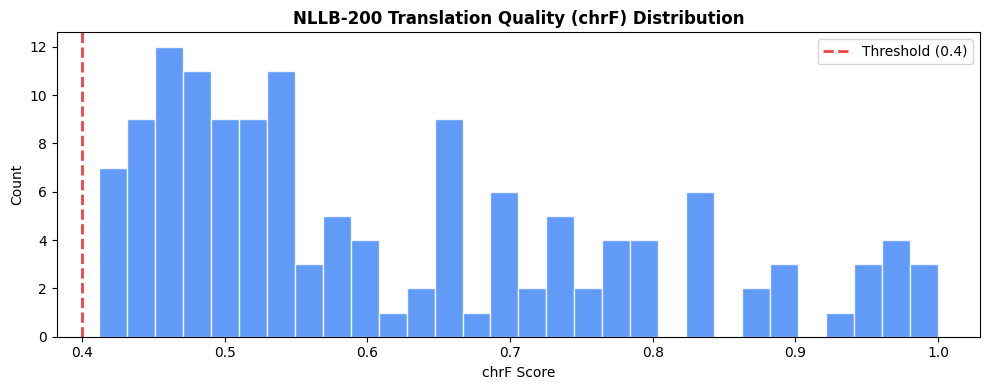

Mean chrF : 0.619
Min chrF  : 0.412


In [4]:
if 'chrf_score' in spam_as.columns:
    plt.figure(figsize=(10, 4))
    plt.hist(spam_as['chrf_score'].dropna(), bins=30,
             color='#3b82f6', alpha=0.8, edgecolor='white')
    plt.axvline(0.4, color='#ef4444', linestyle='--', linewidth=2, label='Threshold (0.4)')
    plt.xlabel('chrF Score')
    plt.ylabel('Count')
    plt.title('NLLB-200 Translation Quality (chrF) Distribution', fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.savefig('../readme-resources/chrf_distribution.png', bbox_inches='tight')
    plt.show()
    print(f'Mean chrF : {spam_as["chrf_score"].mean():.3f}')
    print(f'Min chrF  : {spam_as["chrf_score"].min():.3f}')
else:
    print('chrf_score not in DataFrame (sacrebleu may not be installed).')

## 4. Load Assamese HAM

We first try AI4Bharat IndicCorp (streaming, no download required).  
If unavailable, English HAM is back-translated via NLLB-200.

In [5]:
ham_as = None

try:
    from datasets import load_dataset
    # AI4Bharat IndicCorp — Assamese subset, streaming to avoid full download
    ds = load_dataset('ai4bharat/IndicCorp', 'as', split='train',
                      streaming=True, trust_remote_code=True)
    ham_rows = []
    for i, row in enumerate(ds):
        if i >= 1500: break
        text = row.get('text', '')
        # Keep SMS-length texts (10–500 chars)
        if 10 <= len(text) <= 500:
            ham_rows.append({'text': text, 'label': 0,
                             'language': 'as', 'is_augmented': False})
    ham_as = pd.DataFrame(ham_rows)
    print(f'Real Assamese HAM loaded from IndicCorp: {len(ham_as)} samples')
except Exception as e:
    print(f'IndicCorp unavailable: {e}')
    print('FALLBACK: English HAM will be back-translated (is_augmented=True).')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ai4bharat/IndicCorp' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


IndicCorp unavailable: Dataset 'ai4bharat/IndicCorp' doesn't exist on the Hub or cannot be accessed.
FALLBACK: English HAM will be back-translated (is_augmented=True).


## 5. Build balanced Assamese dataset

In [6]:
df_as = build_assamese_dataset(
    english_df=df_en,
    assamese_ham_df=ham_as,   # None → back-translate English HAM
    chrf_threshold=0.4,
    device=None,
    seed=42,
)

print('\nAssamese dataset summary:')
print(df_as.groupby(['label', 'is_augmented']).size())
df_as.head(4)

[augment] Step 1/4: 747 English SPAM rows selected.
[augment] Step 2/4: Translating to Assamese via NLLB-200...


Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Translated 8/747 samples


Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Translated 48/747 samples


...

Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Translated 128/138 samples


Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Translated 138/138 samples
[augment] Final Assamese dataset: 138 SPAM, 138 HAM

Assamese dataset summary:
label  is_augmented
0      True            138
1      True            138
dtype: int64


,text,label,language,is_augmented
0,WRC ৰেলীত অংশগ্ৰহণ কৰিবলৈ 2 লাগে? আপুনি কৰিব প...,1,as,True
1,goldviking (29/M) য়ে আপোনাক তেওঁৰ বন্ধু হ'বলৈ...,1,as,True
2,"যেতিয়া আপুনি প্ৰেমত পৰে তেতিয়া লক্ষণসমূহঃ ""১...",0,as,True
3,Natalie( 20/F) তেওঁৰ বন্ধু 'হবলৈ আমন্ত্ৰণ কৰিছ...,1,as,True


## 6. Save to disk

In [7]:
out_path = DATA_DIR / 'assamese_augmented.csv'
df_as.to_csv(out_path, index=False)
size_kb = out_path.stat().st_size / 1024
print(f'Saved: {out_path}  ({size_kb:.1f} KB)')
print('\nNext: run notebook 02_feature_engineering.ipynb to include Assamese in the unified dataset.')

Saved: ..\data\assamese_augmented.csv  (56.1 KB)

Next: run notebook 02_feature_engineering.ipynb to include Assamese in the unified dataset.


## 7. Sample translations

Inspect a few Assamese SPAM translations to spot-check quality.

In [1]:
import pandas as pd
df_as = pd.read_csv('../data/assamese_augmented.csv')

print('=== Sample Assamese SPAM translations (NLLB-200) ===')
for i, row in df_as[df_as['label']==1].head(5).iterrows():
    print(f'[{i}] {row["text"][:120]}')
    print()
print('=== Sample Assamese HAM ===')
for i, row in df_as[df_as['label']==0].head(3).iterrows():
    print(f'[{i}] {row["text"][:120]} | aug={row["is_augmented"]}')
    print()

=== Sample Assamese SPAM translations (NLLB-200) ===
[0] WRC ৰেলীত অংশগ্ৰহণ কৰিবলৈ 2 লাগে? আপুনি কৰিব পাৰে Lucozade Eneryg! Text RALLY LE to 61200 (25p), বা lucozade.co.uk/wrc চ

[1] goldviking (29/M) য়ে আপোনাক তেওঁৰ বন্ধু হ'বলৈ আমন্ত্ৰণ কৰিছে। দিয়ক YES-762 বা NO-762 তেওঁক চাওকঃ www.SMS.cau//glodviki

[3] Natalie( 20/F) তেওঁৰ বন্ধু 'হবলৈ আমন্ত্ৰণ কৰিছে। উত্তৰ দিয়ক বা NO-165 তেওঁক চাওকঃ www.SMS.ac/u/natalie2k9 STOP? 62486লৈ

[10] আপনুি EURO2004 CUP FINAL বা £800 CASHলৈ টকিট লাভ কৰিছে, কল 09058099801 b4190604, POOBX 7876150ppm

[11] জৰুৰী! আপুনি আমাৰ পুৰস্কা ৰজ্যাকপটত ১ সপ্তাহৰ বিনামূলীয়া সদস্যতা লাভ কৰিছে! Txt the word: CLAIM to No: 8101 0T&C www.db

=== Sample Assamese HAM ===
[2] যেতিয়া আপুনি প্ৰেমত পৰে তেতিয়া লক্ষণসমূহঃ "১.আপুনি গীত শুনি ভাল পায় ২.আপুনি আপোনাৰ প্ৰিয়জনৰ নাম দেখি থিয় হৈ থাকে ৩. | aug=True

[4] বাইদেউ, অনুমান কৰক কেইদিনমান আগতে কাৰোবাক আটক কৰা হৈছিল। | aug=True

[5] বাছ টুপৰ দিশে আগবাঢ়িছে | aug=True



## Summary

| Parameter | Value |
|-----------|-------|
| Translation model | `facebook/nllb-200-distilled-600M` |
| Source → Target | `eng_Latn` → `asm_Beng` |
| chrF threshold | 0.4 |
| Word dropout p | 0.05 |
| Char swap p | 0.02 |
| is_augmented | True for ALL synthetic samples |
| HuggingFace auth | **Not required** |